In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [37]:
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

In [38]:
from sklearn.model_selection import StratifiedShuffleSplit

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=40, random_state=42)
train_valid_idx, test_idx = next(strat_split.split(olivetti.data,
                                                   olivetti.target))
X_train_valid = olivetti.data[train_valid_idx]
y_train_valid = olivetti.target[train_valid_idx]
X_test = olivetti.data[test_idx]
y_test = olivetti.target[test_idx]

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=80, random_state=43)
train_idx, valid_idx = next(strat_split.split(X_train_valid, y_train_valid))
X_train = X_train_valid[train_idx]
y_train = y_train_valid[train_idx]
X_valid = X_train_valid[valid_idx]
y_valid = y_train_valid[valid_idx]

In [41]:
from sklearn.decomposition import PCA

pca = PCA(0.99)
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.fit(X_valid)
X_test_pca = pca.fit(X_test)

In [44]:
from sklearn.cluster import KMeans

k_range = range(5, 150, 5)
kmeans_per_k = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_pca)
    kmeans_per_k.append(kmeans)

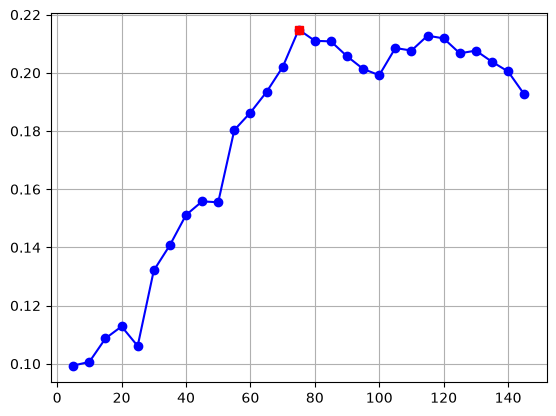

In [52]:
from sklearn.metrics import silhouette_score

silhouette_scores = [silhouette_score(X_train_pca, model.labels_) for model in kmeans_per_k]

best_index = np.argmax(silhouette_scores)
best_score = silhouette_scores[best_index]
best_k = k_range[best_index]
plt.plot(k_range, silhouette_scores, marker='o', linestyle='-', color='b')
plt.plot(best_k, best_score, "rs")
plt.grid()
plt.show()

In [54]:
best_model = kmeans_per_k[best_index]

In [ ]:
def plot_face(faces, labels, n_cols = 10):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1

    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap='gray')
        plt.axis("off")
        plt.title(label)
    plt.tight_layout()
    plt.show()

for cluster_id in np.unique(best_model.labels_):
    print('Cluster: ', cluster_id)
    in_cluster = (best_model.labels_ == cluster_id)
    faces = X_train[in_cluster]
    labels = y_train[in_cluster]
    plot_face(faces, labels)